# PG3 Final Royalty Valuation Tool

Finales Bewertungs- und Risiko-Notebook für den PG3-Fall.  
Dieses Notebook verbindet deterministische Kalibrierung, stochastische Bewertung, Szenarioanalyse, Driver Analysis und ein praxisorientiertes Investment Decision Framework.

**Zielsetzung:**  
- praxisfähige Investment-Entscheidungsunterstützung für PG3  
- wissenschaftlich fundierte Modelllogik für die Bachelorarbeit  
- transparente, reproduzierbare und exportierbare Ergebnisse

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

# Robustere Projektwurzel:
# Das Notebook liegt in /notebooks, deshalb eine Ebene nach oben.
project_root = Path().resolve().parent
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pir_waterfall_engine import (
    WaterfallParams,
    ScenarioSeries,
    compute_waterfall,
    summarize_outputs,
)

from src.metrics import (
    irr_annual,
    moic,
    payback_period,
    deal_metrics,
    monte_carlo_risk_metrics,
    npv_annual,
)

from src.mc import (
    run_pg3_monte_carlo,
    summarize_pg3_mc,
)

from src.calibration import run_calibration

np.random.seed(42)

## 2. User Inputs & Deal Configuration

In [2]:
# ============================================
# DEAL INPUT CONFIG (PG3 STYLE)
# ============================================

DEAL_INPUT = {
    
    # ----------------------------------------
    # Contract / Asset
    # ----------------------------------------
    "initial_cashflow": 50_000_000,
    "growth_rate": 0.03,
    "contract_length": 15,
    
    # ----------------------------------------
    # Valuation
    # ----------------------------------------
    "entry_multiple": 13.9,
    "exit_multiple": 12.0,
    
    # ----------------------------------------
    # Capital Structure
    # ----------------------------------------
    "entry_debt": 325_000_000,
    "ltv_target": 0.5,
    
    # ----------------------------------------
    # Fees
    # ----------------------------------------
    "operating_fee": 0.05,
    "consortium_fee": 0.0008,
    
    # ----------------------------------------
    # Macro
    # ----------------------------------------
    "discount_rate": 0.10,
    
    # ----------------------------------------
    # Simulation
    # ----------------------------------------
    "n_simulations": 5000,
    "volatility": 0.15,
}

In [3]:
# ======================================
# CANONICAL MODEL INPUTS (FROM DEAL_INPUT)
# ======================================

# --- Base deal economics
INITIAL_CASHFLOW = DEAL_INPUT["initial_cashflow"]
GROWTH_RATE = DEAL_INPUT["growth_rate"]
CONTRACT_LENGTH = DEAL_INPUT["contract_length"]

# --- Valuation / entry-exit assumptions
ENTRY_MULTIPLE = DEAL_INPUT["entry_multiple"]
EXIT_MULTIPLE = DEAL_INPUT["exit_multiple"]
DISCOUNT_RATE = DEAL_INPUT["discount_rate"]

# --- Capital structure / leverage
ENTRY_DEBT = DEAL_INPUT["entry_debt"]
LTV_TARGET = DEAL_INPUT["ltv_target"]

# --- Fees
OPERATING_FEE = DEAL_INPUT["operating_fee"]
CONSORTIUM_FEE = DEAL_INPUT["consortium_fee"]

# --- Simulation settings
N_SIM = DEAL_INPUT["n_simulations"]
SIGMA_CF = DEAL_INPUT["volatility"]

# --- Optional / PG3-specific assumptions
PG_SHARE = DEAL_INPUT.get("pg_share", 0.2954)
INTEREST_RATE = DEAL_INPUT.get("interest_rate", 0.06)

# --- Derived helper metrics
ENTRY_EV = INITIAL_CASHFLOW * ENTRY_MULTIPLE
ENTRY_EQUITY = ENTRY_EV - ENTRY_DEBT
IMPLIED_ENTRY_LTV = ENTRY_DEBT / ENTRY_EV if ENTRY_EV != 0 else np.nan

print("✅ Canonical model inputs created")
print(f"Entry EV: {ENTRY_EV:,.2f}")
print(f"Entry Equity: {ENTRY_EQUITY:,.2f}")
print(f"Implied Entry LTV: {IMPLIED_ENTRY_LTV:.2%}")

✅ Canonical model inputs created
Entry EV: 695,000,000.00
Entry Equity: 370,000,000.00
Implied Entry LTV: 46.76%


In [4]:
# ======================================
# MASTER CONFIG
# ======================================

CONFIG = {
    # Core operating assumptions
    "initial_cashflow": INITIAL_CASHFLOW,
    "growth_rate": GROWTH_RATE,
    "contract_length": CONTRACT_LENGTH,

    # Valuation assumptions
    "entry_multiple": ENTRY_MULTIPLE,
    "exit_multiple": EXIT_MULTIPLE,
    "discount_rate": DISCOUNT_RATE,

    # Capital structure
    "entry_debt": ENTRY_DEBT,
    "ltv_target": LTV_TARGET,
    "entry_ev": ENTRY_EV,
    "entry_equity": ENTRY_EQUITY,
    "implied_entry_ltv": IMPLIED_ENTRY_LTV,

    # Fees
    "operating_fee": OPERATING_FEE,
    "consortium_fee": CONSORTIUM_FEE,

    # Simulation
    "n_simulations": N_SIM,
    "sigma_cf": SIGMA_CF,

    # Additional assumptions
    "pg_share": PG_SHARE,
    "interest_rate": INTEREST_RATE,
}

print("✅ CONFIG built successfully")
print(pd.Series(CONFIG))

✅ CONFIG built successfully
initial_cashflow     5.000000e+07
growth_rate          3.000000e-02
contract_length      1.500000e+01
entry_multiple       1.390000e+01
exit_multiple        1.200000e+01
discount_rate        1.000000e-01
entry_debt           3.250000e+08
ltv_target           5.000000e-01
entry_ev             6.950000e+08
entry_equity         3.700000e+08
implied_entry_ltv    4.676259e-01
operating_fee        5.000000e-02
consortium_fee       8.000000e-04
n_simulations        5.000000e+03
sigma_cf             1.500000e-01
pg_share             2.954000e-01
interest_rate        6.000000e-02
dtype: float64


## 3. Input Validation

In [5]:
# ======================================
# INPUT VALIDATION
# ======================================

errors = []
warnings = []

required_keys = [
    "initial_cashflow",
    "growth_rate",
    "contract_length",
    "entry_multiple",
    "exit_multiple",
    "discount_rate",
    "entry_debt",
    "ltv_target",
    "operating_fee",
    "consortium_fee",
    "n_simulations",
    "sigma_cf",
]

for key in required_keys:
    if key not in CONFIG:
        errors.append(f"Missing CONFIG key: {key}")

# --- Level checks
if CONFIG["initial_cashflow"] <= 0:
    errors.append("initial_cashflow must be > 0")

if CONFIG["contract_length"] <= 0:
    errors.append("contract_length must be > 0")

if CONFIG["entry_multiple"] <= 0:
    errors.append("entry_multiple must be > 0")

if CONFIG["exit_multiple"] <= 0:
    errors.append("exit_multiple must be > 0")

if CONFIG["discount_rate"] <= 0:
    errors.append("discount_rate must be > 0")

if CONFIG["entry_debt"] < 0:
    errors.append("entry_debt cannot be negative")

if CONFIG["ltv_target"] <= 0 or CONFIG["ltv_target"] > 1:
    errors.append("ltv_target must be between 0 and 1")

if CONFIG["operating_fee"] < 0:
    errors.append("operating_fee cannot be negative")

if CONFIG["consortium_fee"] < 0:
    errors.append("consortium_fee cannot be negative")

if CONFIG["n_simulations"] < 100:
    errors.append("n_simulations must be at least 100")

if CONFIG["sigma_cf"] < 0:
    errors.append("sigma_cf cannot be negative")

# --- Soft warnings
if CONFIG["n_simulations"] < 1000:
    warnings.append("n_simulations < 1000. Results may be unstable.")

if CONFIG["discount_rate"] > 0.20:
    warnings.append("discount_rate > 20%. Check whether this is intentional.")

if CONFIG["implied_entry_ltv"] > 0.70:
    warnings.append("Implied entry LTV is above 70%.")

if CONFIG["entry_equity"] <= 0:
    errors.append("entry_equity must be > 0. Entry debt exceeds or equals entry EV.")

# --- Final output
if errors:
    print("❌ INPUT VALIDATION FAILED")
    for e in errors:
        print(f" - {e}")
    raise ValueError("Fix input errors before running the model.")

if warnings:
    print("⚠️ INPUT WARNINGS")
    for w in warnings:
        print(f" - {w}")

print("✅ Input validation passed")

✅ Input validation passed


## 4. Load Data (PG3 Ground Truth)

In [6]:
# ======================================
# LOAD PG3 GROUND TRUTH
# ======================================

gt_path = project_root / "Data" / "processed" / "ground_truth_clean.csv"
gt_df = pd.read_csv(gt_path)

print("Ground-truth path:", gt_path)
print("\nColumns:")
print(gt_df.columns.tolist())

print("\nPreview:")
display(gt_df.head())

Ground-truth path: C:\Users\Noah\PG3_Royalty_Python_Model\Data\processed\ground_truth_clean.csv

Columns:
['Scenario', 'FY', 'Net_CF_to_Consortium', 'Op_Fee', 'Consortium_Fees', 'CF_after_Fees', 'Interest_Rate', 'Interest_Cost', 'Mandatory_Amort', 'Recap_DeltaDebt', 'Cash_Sweep', 'Debt_End', 'FCF_for_Distribution', 'NAV_Multiple', 'NAV', 'LTV', 'PG_Share', 'Equity_Ticket', 'Equity_CF']

Preview:


,Scenario,FY,Net_CF_to_Consortium,Op_Fee,Consortium_Fees,CF_after_Fees,Interest_Rate,Interest_Cost,Mandatory_Amort,Recap_DeltaDebt,Cash_Sweep,Debt_End,FCF_for_Distribution,NAV_Multiple,NAV,LTV,PG_Share,Equity_Ticket,Equity_CF
0,Base,2024,46.8,2.340,0.2,44.260,0.062,-20.15000,0.0,0.00,0.0,325.00,24.11000,14.0,655.20,0.496032,0.295394,99.4,-92.278056
1,Base,2025,50.3,2.515,0.0,47.785,0.056,-18.20000,0.0,0.00,0.0,325.00,29.58500,14.0,704.20,0.461517,0.295394,99.4,8.739224
2,Base,2026,53.7,2.685,0.0,51.015,0.057,-18.52500,0.0,126.08,0.0,451.08,32.49000,14.0,751.80,0.600000,0.295394,99.4,9.597343
3,Base,2027,56.3,2.815,0.0,53.485,0.057,-25.71156,0.0,0.00,0.0,451.08,27.77344,14.0,788.20,0.572291,0.295394,99.4,8.204101
4,Base,2028,58.3,2.915,0.0,55.385,0.059,-26.61372,0.0,0.00,0.0,451.08,28.77128,13.6,792.88,0.568913,0.295394,99.4,8.498857


## 5. Deterministic Base Case (DCF)

In [7]:
# ======================================
# BUILD CLEAN PG3 SCENARIO
# ======================================

# Nur Zeilen verwenden, wo operativer Cashflow existiert
gt_clean = gt_df[gt_df["Net_CF_to_Consortium"].notna()].copy()

fy = gt_clean["FY"].to_numpy()
net_cf = gt_clean["Net_CF_to_Consortium"].to_numpy(dtype=float)
interest_rate = gt_clean["Interest_Rate"].to_numpy(dtype=float)
nav_multiple = gt_clean["NAV_Multiple"].to_numpy(dtype=float)
mandatory_amort = gt_clean["Mandatory_Amort"].to_numpy(dtype=float)
consortium_fees = gt_clean["Consortium_Fees"].to_numpy(dtype=float)

series_pg3 = ScenarioSeries(
    fy=fy,
    net_cf_to_consortium=net_cf,
    interest_rate=interest_rate,
    nav_multiple=nav_multiple,
    mandatory_amort=mandatory_amort,
    consortium_fees=consortium_fees,
)

print("Length FY:", len(fy))
print("Length CF:", len(net_cf))
print("First FY:", fy[0], "| Last FY:", fy[-1])

Length FY: 16
Length CF: 16
First FY: 2024 | Last FY: 2039


### Deal-Level Base Case

In [8]:
# ======================================
# RUN DETERMINISTIC PG3 BASE CASE
# ======================================

# WICHTIG:
# Ground-truth / waterfall engine arbeitet hier in "Millionen"-Einheiten.
# Deshalb werden absolute DEAL_INPUT / CONFIG Werte auf Millionen skaliert.

UNIT_SCALE = 1_000_000

# --- Entry valuation (CONFIG-driven, unit-adjusted)
entry_ev = CONFIG["entry_ev"] / UNIT_SCALE
entry_debt = CONFIG["entry_debt"] / UNIT_SCALE

# --- Sanity check
implied_ltv = entry_debt / entry_ev
print(f"Implied LTV (Base Case): {implied_ltv:.2%}")

# --- Equity ticket
# Für den PG3-Base-Case muss das Equity Ticket dem PG-Anteil entsprechen,
# nicht dem gesamten Deal-Equity.
entry_equity_total = entry_ev - entry_debt
entry_equity_pg = entry_equity_total * CONFIG["pg_share"]

# --- Parameter object
params_pg3 = WaterfallParams(
    scenario="PG3_Base",
    entry_debt=entry_debt,
    recap_target_ltv=CONFIG["ltv_target"],
    recap_years=(fy[3], fy[6]),
    cash_sweep_start_fy=fy[2],
    operating_fee_pct=CONFIG["operating_fee"],
    pg_share=CONFIG["pg_share"],
    consortium_equity_ticket=entry_equity_pg,
)

# --- Run waterfall
wf_pg3 = compute_waterfall(params_pg3, series_pg3)
outs_pg3 = summarize_outputs(params_pg3, wf_pg3)

print("PG3 Deterministic IRR:", outs_pg3["IRR (annual)"])
print("PG3 MOIC:", outs_pg3["MOIC"])

display(wf_pg3.head())

Implied LTV (Base Case): 46.76%
PG3 Deterministic IRR: 0.10323959328084861
PG3 MOIC: 2.551169081081081


,FY,Net CF to Consortium,Op Fee,Consortium Fees,CF after Fees,Interest Rate,Interest Cost,Mandatory Amort,Recap ΔDebt,Cash Sweep,Debt Begin,Debt End,NAV Multiple,NAV,LTV,FCF for Distribution
0,2024,46.8,2.340,0.2,44.260,0.062,-20.1500,0.0,0.0,0.0,325.0,325.0,14.0,655.20,0.496032,24.1100
1,2025,50.3,2.515,0.0,47.785,0.056,-18.2000,0.0,0.0,0.0,325.0,325.0,14.0,704.20,0.461517,29.5850
2,2026,53.7,2.685,0.0,51.015,0.057,-18.5250,0.0,0.0,0.0,325.0,325.0,14.0,751.80,0.432296,32.4900
3,2027,56.3,2.815,0.0,53.485,0.057,-18.5250,0.0,69.1,0.0,325.0,394.1,14.0,788.20,0.500000,34.9600
4,2028,58.3,2.915,0.0,55.385,0.059,-23.2519,0.0,0.0,0.0,394.1,394.1,13.6,792.88,0.497049,32.1331


## 6. Calibration Check (Excel vs. Python)

In [9]:
# ======================================
# CALIBRATION AGAINST GROUND TRUTH
# ======================================

cal_results = run_calibration(
    csv_path=project_root / "Data" / "processed" / "ground_truth_clean.csv",
    output_dir=project_root / "outputs",
    scenario="Base",
    recap_target_ltv=0.60,
)

metric_comparison = cal_results["metric_comparison"].copy()
yearly_comparison = cal_results["yearly_comparison"].copy()
summary_comparison = cal_results["summary"].copy()

display(metric_comparison)

,metric,excel_value,python_value,abs_diff,rel_diff
0,equity_ticket,99.400000,99.400000,0.000000e+00,0.000000e+00
1,pg_share,0.295394,0.295394,0.000000e+00,0.000000e+00
2,irr,0.097465,0.097465,0.000000e+00,0.000000e+00
3,moic,2.477629,2.477629,-4.440892e-16,-1.792396e-16
4,total_equity_cf,136.352731,136.352731,-8.526513e-14,-6.253276e-16
5,total_distributions,228.630788,228.630788,-5.684342e-14,-2.486254e-16
6,terminal_equity_cf,100.067590,100.067590,-2.842171e-14,-2.840251e-16
7,final_debt_end,471.240000,471.240000,-5.684342e-14,-1.206252e-16
8,final_fcf_distribution,338.760000,338.760000,0.000000e+00,0.000000e+00


In [10]:
# ======================================
# CALIBRATION STATUS
# ======================================

max_delta = metric_comparison["abs_diff"].max()

if max_delta < 1e-6:
    calibration_status = "PASS"
elif max_delta < 1e-3:
    calibration_status = "WARNING"
else:
    calibration_status = "FAIL"

print(f"Calibration Status: {calibration_status}")
print(f"Max deviation: {max_delta:.6f}")

Calibration Status: PASS
Max deviation: 0.000000


### Calibration Summary Table

In [11]:
# ======================================
# HEADLINE CALIBRATION TABLE
# ======================================

discount_rate_cal = 0.10

metric_lookup = metric_comparison.set_index("metric")

def get_metric_value(metric_name: str, value_col: str) -> float:
    return float(metric_lookup.loc[metric_name, value_col])

gt_equity_cf = yearly_comparison["gt_Equity_CF"].to_numpy(dtype=float)
py_equity_cf = yearly_comparison["py_Equity_CF"].to_numpy(dtype=float)

excel_npv = float(npv_annual(gt_equity_cf, discount_rate_cal))
python_npv = float(npv_annual(py_equity_cf, discount_rate_cal))

headline_rows = [
    {
        "metric": "IRR",
        "excel_value": get_metric_value("irr", "excel_value"),
        "python_value": get_metric_value("irr", "python_value"),
    },
    {
        "metric": "MOIC",
        "excel_value": get_metric_value("moic", "excel_value"),
        "python_value": get_metric_value("moic", "python_value"),
    },
    {
        "metric": f"Deterministic NPV @ {discount_rate_cal:.0%}",
        "excel_value": excel_npv,
        "python_value": python_npv,
    },
]

headline_comparison = pd.DataFrame(headline_rows)
headline_comparison["delta"] = headline_comparison["python_value"] - headline_comparison["excel_value"]

headline_comparison["excel_value"] = headline_comparison["excel_value"].round(6)
headline_comparison["python_value"] = headline_comparison["python_value"].round(6)
headline_comparison["delta"] = headline_comparison["delta"].round(6)
headline_comparison["delta"] = headline_comparison["delta"].replace(-0.0, 0.0)

display(headline_comparison)

,metric,excel_value,python_value,delta
0,IRR,0.097465,0.097465,0.0
1,MOIC,2.477629,2.477629,0.0
2,Deterministic NPV @ 10%,-1.796007,-1.796007,0.0


### Selected Yearly Comparison

In [12]:
# ======================================
# SELECTED YEARLY COMPARISON
# ======================================

key_years = [2024, 2030, 2039]

equity_cf_comparison = (
    yearly_comparison.loc[
        yearly_comparison["FY"].isin(key_years),
        ["FY", "gt_Equity_CF", "py_Equity_CF"]
    ]
    .copy()
    .reset_index(drop=True)
)

equity_cf_comparison["delta"] = (
    equity_cf_comparison["py_Equity_CF"] - equity_cf_comparison["gt_Equity_CF"]
)

equity_cf_comparison["gt_Equity_CF"] = equity_cf_comparison["gt_Equity_CF"].round(6)
equity_cf_comparison["py_Equity_CF"] = equity_cf_comparison["py_Equity_CF"].round(6)
equity_cf_comparison["delta"] = equity_cf_comparison["delta"].round(6)
equity_cf_comparison["delta"] = equity_cf_comparison["delta"].replace(-0.0, 0.0)

display(equity_cf_comparison)

,FY,gt_Equity_CF,py_Equity_CF,delta
0,2024,-92.278056,-92.278056,0.0
1,2030,8.569550,8.569550,0.0
2,2039,100.067590,100.067590,0.0


## 7. Monte Carlo Simulation

In [13]:
# ======================================
# PG3 MONTE CARLO BASE RUN
# ======================================

pg3_mc_out = run_pg3_monte_carlo(
    base_df=gt_clean,
    exit_multiple_mean=12.0,
    exit_multiple_sigma=1.5,
    n_sim=1000,
    random_state=42,
    operating_fee_rate=0.05,
    consortium_fee_rate=0.0008,
    interest_rate=0.06,
    amort_rate=0.0,
    cash_sweep_rate=0.0,
    recap_year=None,
    recap_amount=0.0,
)

pg3_mc_summary = summarize_pg3_mc(pg3_mc_out)

print("PG3 MONTE CARLO SUMMARY")
print("-----------------------")
for k, v in pg3_mc_summary.items():
    print(f"{k}: {round(v, 4)}")

PG3 MONTE CARLO SUMMARY
-----------------------
irr_mean: 0.1038
irr_p10: 0.0861
irr_p50: 0.1036
irr_p90: 0.1215
moic_mean: 2.7995
moic_p10: 2.1659
moic_p50: 2.7509
moic_p90: 3.5187
net_cf_mean: 178.8708
net_cf_p10: 115.8934
net_cf_p50: 174.0346
net_cf_p90: 250.3588
terminal_value_mean: 99.1527
terminal_value_p10: 42.1237
terminal_value_p50: 95.4628
terminal_value_p90: 165.2031
npv_mean: 4.2291
npv_p10: -10.2466
npv_p50: 2.783
npv_p90: 20.4022


### Risk Metrics

In [14]:
# ======================================
# PG3 MONTE CARLO RISK METRICS
# ======================================

pg3_mc_risk = monte_carlo_risk_metrics(
    {
        "irr": pg3_mc_out["irr"],
        "moic": pg3_mc_out["moic"],
        "net_cf": pg3_mc_out["net_cf"],
        "npv": pg3_mc_out["npv"],
        "payback_period": np.full_like(pg3_mc_out["irr"], np.nan, dtype=float),
    },
    alpha=0.05,
)

print("PG3 MONTE CARLO RISK METRICS")
print("----------------------------")
for k, v in pg3_mc_risk.items():
    print(f"{k}: {round(v, 4)}")

PG3 MONTE CARLO RISK METRICS
----------------------------
prob_irr_negative: 0.0
prob_moic_below_1x: 0.0
prob_net_cf_negative: 0.0
prob_no_payback: 1.0
irr_var_5: 0.0798
irr_cvar_5: 0.0745
net_cf_var_5: 104.4034
net_cf_cvar_5: 90.5652
prob_npv_negative: 0.406
npv_var_5: -13.9173
npv_cvar_5: -16.9908


### Distribution Plot

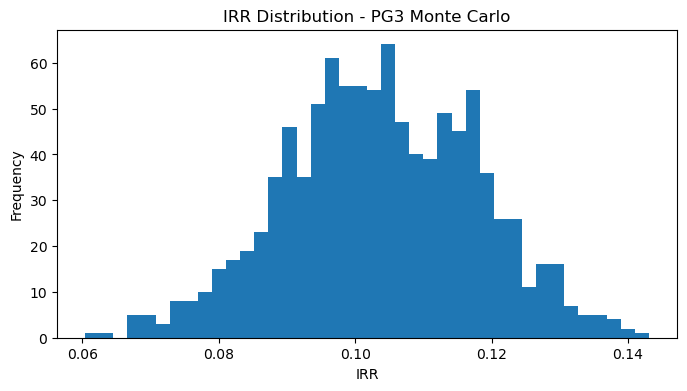

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(pg3_mc_out["irr"], bins=40)
plt.title("IRR Distribution - PG3 Monte Carlo")
plt.xlabel("IRR")
plt.ylabel("Frequency")
plt.show()

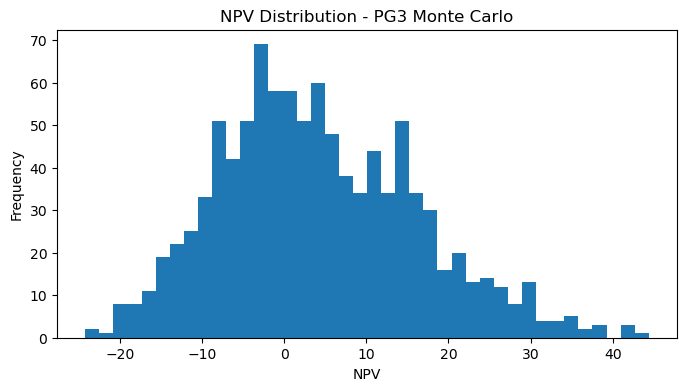

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(pg3_mc_out["npv"], bins=40)
plt.title("NPV Distribution - PG3 Monte Carlo")
plt.xlabel("NPV")
plt.ylabel("Frequency")
plt.show()

### Unified Simulation Engine

In [17]:
# ======================================
# UNIFIED PG3 SIMULATION ENGINE
# ======================================

def run_sim(config, base_df):
    """
    Zentrale Simulationsfunktion für das PG3 Royalty Modell.

    Liefert:
    - Deterministic Deal-Level Results
    - Monte Carlo Summary
    - Risk Metrics
    - Raw MC Outputs
    """

    # =========================
    # 1. Extract Config
    # =========================
    NSIM = config["n_simulations"]
    SIGMA_CF = config["sigma_cf"]
    SIGMA_MULTIPLE = config.get("sigma_multiple", 0.20)
    DISCOUNT_RATE = config["discount_rate"]

    EXIT_MULTIPLE = config["exit_multiple"]
    OPERATING_FEE = config["operating_fee"]
    CONSORTIUM_FEE = config["consortium_fee"]
    INTEREST_RATE = config["interest_rate"]

    ENTRY_EV = config["entry_ev"]
    ENTRY_DEBT = config["entry_debt"]
    PG_SHARE = config["pg_share"]
    LTV_TARGET = config["ltv_target"]

    # =========================
    # 2. Deterministic Run (Config-Driven)
    # =========================
    UNIT_SCALE = 1_000_000

    entry_ev_tmp = ENTRY_EV / UNIT_SCALE
    entry_debt_tmp = ENTRY_DEBT / UNIT_SCALE
    entry_equity_total_tmp = entry_ev_tmp - entry_debt_tmp
    entry_equity_pg_tmp = entry_equity_total_tmp * PG_SHARE

    params_tmp = WaterfallParams(
        scenario="Sim_Config_Run",
        entry_debt=entry_debt_tmp,
        recap_target_ltv=LTV_TARGET,
        recap_years=(fy[3], fy[6]),
        cash_sweep_start_fy=fy[2],
        operating_fee_pct=OPERATING_FEE,
        pg_share=PG_SHARE,
        consortium_equity_ticket=entry_equity_pg_tmp,
    )

    wf_tmp = compute_waterfall(params_tmp, series_pg3)
    outs_tmp = summarize_outputs(params_tmp, wf_tmp)

    det_summary = {
        "irr": outs_tmp["IRR (annual)"],
        "moic": outs_tmp["MOIC"],
    }

    # =========================
    # 3. Monte Carlo Simulation
    # =========================
    mc_out = run_pg3_monte_carlo(
        base_df=base_df,
        exit_multiple_mean=EXIT_MULTIPLE,
        exit_multiple_sigma=SIGMA_MULTIPLE,
        n_sim=NSIM,
        random_state=42,
        discount_rate=DISCOUNT_RATE,
        sigma_cf=SIGMA_CF,
        operating_fee_rate=OPERATING_FEE,
        consortium_fee_rate=CONSORTIUM_FEE,
        interest_rate=INTEREST_RATE,
        amort_rate=0.0,
        cash_sweep_rate=0.0,
        recap_year=None,
        recap_amount=0.0,
    )

    # =========================
    # 3B. Simple leverage / equity overlay
    # =========================
    BASE_ENTRY_DEBT = CONFIG["entry_debt"]
    BASE_ENTRY_EV = CONFIG["entry_ev"]

    base_equity = BASE_ENTRY_EV - BASE_ENTRY_DEBT
    current_equity = ENTRY_EV - ENTRY_DEBT

    equity_scale = current_equity / base_equity if base_equity > 0 else 1.0

    mc_out["npv"] = mc_out["npv"] * equity_scale
    mc_out["moic"] = mc_out["moic"] * equity_scale

    leverage_ratio = ENTRY_DEBT / ENTRY_EV if ENTRY_EV > 0 else 0
    base_leverage_ratio = BASE_ENTRY_DEBT / BASE_ENTRY_EV if BASE_ENTRY_EV > 0 else 0
    irr_shift = (leverage_ratio - base_leverage_ratio) * 0.02
    mc_out["irr"] = mc_out["irr"] + irr_shift

    # =========================
    # 4. Summaries
    # =========================
    mc_summary = summarize_pg3_mc(mc_out)

    risk = monte_carlo_risk_metrics(
        {
            "irr": mc_out["irr"],
            "moic": mc_out["moic"],
            "net_cf": mc_out["net_cf"],
            "npv": mc_out["npv"],
            "payback_period": np.full_like(mc_out["irr"], np.nan, dtype=float),
        },
        alpha=0.05,
    )

    # =========================
    # 5. Bundle Results
    # =========================
    results = {
        "deterministic": det_summary,
        "monte_carlo": mc_summary,
        "risk": risk,
        "raw_mc": mc_out,
        "used_config": {
            "n_simulations": NSIM,
            "sigma_cf": SIGMA_CF,
            "sigma_multiple": SIGMA_MULTIPLE,
            "discount_rate": DISCOUNT_RATE,
            "exit_multiple": EXIT_MULTIPLE,
            "operating_fee": OPERATING_FEE,
            "consortium_fee": CONSORTIUM_FEE,
            "interest_rate": INTEREST_RATE,
            "entry_ev": ENTRY_EV,
            "entry_debt": ENTRY_DEBT,
            "ltv_target": LTV_TARGET,
            "pg_share": PG_SHARE,
        },
    }

    return results

In [18]:
# RUN MASTER SIMULATION

results = run_sim(CONFIG, gt_clean)

print("DETERMINISTIC (Deal-Level)")
print(results["deterministic"])

print("\nMONTE CARLO SUMMARY")
for k, v in results["monte_carlo"].items():
    print(f"{k}: {round(v, 4)}")

print("\nRISK METRICS")
for k, v in results["risk"].items():
    print(f"{k}: {round(v, 4)}")

DETERMINISTIC (Deal-Level)
{'irr': 0.10323959328084861, 'moic': 2.551169081081081}

MONTE CARLO SUMMARY
irr_mean: 0.1048
irr_p10: 0.0897
irr_p50: 0.1049
irr_p90: 0.1196
moic_mean: 2.8167
moic_p10: 2.3074
moic_p50: 2.7909
moic_p90: 3.3655
net_cf_mean: 180.5787
net_cf_p10: 129.9508
net_cf_p50: 178.0178
net_cf_p90: 235.127
terminal_value_mean: 100.7489
terminal_value_p10: 54.671
terminal_value_p50: 98.4502
terminal_value_p90: 149.4901
npv_mean: 4.6548
npv_p10: -7.8422
npv_p50: 4.0526
npv_p90: 17.7264

RISK METRICS
prob_irr_negative: 0.0
prob_moic_below_1x: 0.0
prob_net_cf_negative: 0.0
prob_no_payback: 1.0
irr_var_5: 0.0853
irr_cvar_5: 0.0801
net_cf_var_5: 117.3718
net_cf_cvar_5: 105.656
prob_npv_negative: 0.3374
npv_var_5: -10.6067
npv_cvar_5: -14.0525


## 8. Scenario & Macro Analysis

### Makroökonomische Wirkungslogik (Macro Transmission Logic)

Die definierten Makro-Szenarien sind als Bewertungsregime zu verstehen und nicht als exakte volkswirtschaftliche Prognosen.

Wirkungskanäle:
- Zinsniveau → Diskontsatz → Barwert der Cashflows
- Makroökonomische Abschwächung → tiefere Exit-Multiples → geringerer Terminal Value
- Erhöhte Unsicherheit → potenziell höhere Cashflow-Volatilität

Interpretation:
Die Szenarien dienen als strukturierte Stress- und Sensitivitätsanalyse der Bewertung und sollen die Robustheit des Investments unter unterschiedlichen Kapitalmarktbedingungen abbilden.

In [19]:
# ======================================
# MACRO SCENARIOS
# ======================================

macro_scenarios = {
    "Base": {
        "discount_rate": 0.10,
    },
    "High_Rate": {
        "discount_rate": 0.12,
    },
    "Low_Rate": {
        "discount_rate": 0.08,
    },
}

In [20]:
# ======================================
# RUN MACRO SCENARIOS
# ======================================

macro_results = {}

for name, params in macro_scenarios.items():
    config_tmp = CONFIG.copy()
    config_tmp["DISCOUNT_RATE"] = params["discount_rate"]

    res = run_sim(config_tmp, gt_clean)

    # Für zusätzliche Transparenz: NPV nochmals explizit aus der Cashflow-Matrix prüfen
    cashflow_matrix = res["raw_mc"]["cashflow_matrix"]
    discount_rate = params["discount_rate"]

    npv_values = np.array([
        npv_annual(cf_path, discount_rate)
        for cf_path in cashflow_matrix
    ])

    macro_results[name] = {
        "Discount_Rate": discount_rate,
        "IRR_Mean": res["monte_carlo"]["irr_mean"],
        "NPV_Mean": float(np.mean(npv_values)),
        "NPV_P10": float(np.percentile(npv_values, 10)),
        "NPV_CVaR_5": float(np.mean(npv_values[npv_values <= np.percentile(npv_values, 5)])),
        "Prob_NPV_Negative": float(np.mean(npv_values < 0)),
    }

macro_df = pd.DataFrame(macro_results).T
display(macro_df)

,Discount_Rate,IRR_Mean,NPV_Mean,NPV_P10,NPV_CVaR_5,Prob_NPV_Negative
Base,0.10,0.104794,4.654787,-7.842152,-14.052489,0.3374
High_Rate,0.12,0.104794,-10.660622,-20.584257,-25.622639,0.9078
Low_Rate,0.08,0.104794,24.114878,8.046800,0.206980,0.0182


### Discount Rate Sweep

In [21]:
# ======================================
# DISCOUNT RATE SWEEP
# ======================================

discount_grid = [0.08, 0.09, 0.10, 0.11, 0.12]
discount_sweep_results = {}

for dr in discount_grid:
    config_tmp = CONFIG.copy()
    config_tmp["DISCOUNT_RATE"] = dr

    res = run_sim(config_tmp, gt_clean)

    cashflow_matrix = res["raw_mc"]["cashflow_matrix"]

    npv_values = np.array([
        npv_annual(cf_path, dr)
        for cf_path in cashflow_matrix
    ])

    discount_sweep_results[f"{dr:.0%}"] = {
        "NPV_Mean": float(np.mean(npv_values)),
        "NPV_P10": float(np.percentile(npv_values, 10)),
        "NPV_P50": float(np.percentile(npv_values, 50)),
        "NPV_P90": float(np.percentile(npv_values, 90)),
        "Prob_NPV_Negative": float(np.mean(npv_values < 0)),
    }

discount_sweep_df = pd.DataFrame(discount_sweep_results).T
display(discount_sweep_df)

,NPV_Mean,NPV_P10,NPV_P50,NPV_P90,Prob_NPV_Negative
8%,24.114878,8.046800,23.333182,41.018060,0.0182
9%,13.790440,-0.261965,13.109717,28.650967,0.1050
10%,4.654787,-7.842152,4.052577,17.726443,0.3374
11%,-3.450480,-14.606911,-4.023702,8.126022,0.6644
12%,-10.660622,-20.584257,-11.164949,-0.297372,0.9078


## 9. Driver Analysis

In [22]:
# ======================================
# UNIFIED PG3 SIMULATION ENGINE
# ======================================

def run_sim(config, base_df):
    """
    Zentrale Simulationsfunktion für das PG3 Royalty Modell.

    Liefert:
    - Deterministic Deal-Level Results
    - Monte Carlo Summary
    - Risk Metrics
    - Raw MC Outputs
    """

    # =========================
    # 1. Extract Config
    # =========================
    NSIM = config["n_simulations"]
    SIGMA_CF = config["sigma_cf"]
    SIGMA_MULTIPLE = config.get("sigma_multiple", 0.20)
    DISCOUNT_RATE = config["discount_rate"]

    EXIT_MULTIPLE = config["exit_multiple"]
    OPERATING_FEE = config["operating_fee"]
    CONSORTIUM_FEE = config["consortium_fee"]
    INTEREST_RATE = config["interest_rate"]

    ENTRY_EV = config["entry_ev"]
    ENTRY_DEBT = config["entry_debt"]
    PG_SHARE = config["pg_share"]
    LTV_TARGET = config["ltv_target"]

    # =========================
    # 2. Deterministic Run (Config-Driven)
    # =========================
    UNIT_SCALE = 1_000_000

    entry_ev_tmp = ENTRY_EV / UNIT_SCALE
    entry_debt_tmp = ENTRY_DEBT / UNIT_SCALE
    entry_equity_total_tmp = entry_ev_tmp - entry_debt_tmp
    entry_equity_pg_tmp = entry_equity_total_tmp * PG_SHARE

    params_tmp = WaterfallParams(
        scenario="Sim_Config_Run",
        entry_debt=entry_debt_tmp,
        recap_target_ltv=LTV_TARGET,
        recap_years=(fy[3], fy[6]),
        cash_sweep_start_fy=fy[2],
        operating_fee_pct=OPERATING_FEE,
        pg_share=PG_SHARE,
        consortium_equity_ticket=entry_equity_pg_tmp,
    )

    wf_tmp = compute_waterfall(params_tmp, series_pg3)
    outs_tmp = summarize_outputs(params_tmp, wf_tmp)

    det_summary = {
        "irr": outs_tmp["IRR (annual)"],
        "moic": outs_tmp["MOIC"],
    }

    # =========================
    # 3. Monte Carlo Simulation
    # =========================
    mc_out = run_pg3_monte_carlo(
        base_df=base_df,
        exit_multiple_mean=EXIT_MULTIPLE,
        exit_multiple_sigma=SIGMA_MULTIPLE,
        n_sim=NSIM,
        random_state=42,
        discount_rate=DISCOUNT_RATE,
        sigma_cf=SIGMA_CF,
        operating_fee_rate=OPERATING_FEE,
        consortium_fee_rate=CONSORTIUM_FEE,
        interest_rate=INTEREST_RATE,
        amort_rate=0.0,
        cash_sweep_rate=0.0,
        recap_year=None,
        recap_amount=0.0,
    )

    # =========================
    # 3B. Simple leverage / equity overlay
    # =========================
    BASE_ENTRY_DEBT = CONFIG["entry_debt"]
    BASE_ENTRY_EV = CONFIG["entry_ev"]

    base_equity = BASE_ENTRY_EV - BASE_ENTRY_DEBT
    current_equity = ENTRY_EV - ENTRY_DEBT

    equity_scale = current_equity / base_equity if base_equity > 0 else 1.0

    mc_out["npv"] = mc_out["npv"] * equity_scale
    mc_out["moic"] = mc_out["moic"] * equity_scale

    # Optional: slight IRR sensitivity to leverage
    leverage_ratio = ENTRY_DEBT / ENTRY_EV if ENTRY_EV > 0 else 0
    base_leverage_ratio = BASE_ENTRY_DEBT / BASE_ENTRY_EV if BASE_ENTRY_EV > 0 else 0
    irr_shift = (leverage_ratio - base_leverage_ratio) * 0.02
    mc_out["irr"] = mc_out["irr"] + irr_shift

    # =========================
    # 4. Summaries
    # =========================
    mc_summary = summarize_pg3_mc(mc_out)

    risk = monte_carlo_risk_metrics(
        {
            "irr": mc_out["irr"],
            "moic": mc_out["moic"],
            "net_cf": mc_out["net_cf"],
            "npv": mc_out["npv"],
            "payback_period": np.full_like(mc_out["irr"], np.nan, dtype=float),
        },
        alpha=0.05,
    )

    # =========================
    # 5. Bundle Results
    # =========================
    results = {
        "deterministic": det_summary,
        "monte_carlo": mc_summary,
        "risk": risk,
        "raw_mc": mc_out,
        "used_config": {
            "n_simulations": NSIM,
            "sigma_cf": SIGMA_CF,
            "sigma_multiple": SIGMA_MULTIPLE,
            "discount_rate": DISCOUNT_RATE,
            "exit_multiple": EXIT_MULTIPLE,
            "operating_fee": OPERATING_FEE,
            "consortium_fee": CONSORTIUM_FEE,
            "interest_rate": INTEREST_RATE,
            "entry_ev": ENTRY_EV,
            "entry_debt": ENTRY_DEBT,
            "ltv_target": LTV_TARGET,
            "pg_share": PG_SHARE,
        },
    }

    return results

In [23]:
# ======================================
# DRIVER ANALYSIS (VALUE + RISK DRIVERS)
# ======================================

driver_results = []

base_discount_rate = CONFIG["discount_rate"]
base_exit_multiple = CONFIG["exit_multiple"]
base_volatility = CONFIG["sigma_cf"]
base_ltv = CONFIG["ltv_target"]

driver_scenarios = {
    "discount_rate": [base_discount_rate - 0.01, base_discount_rate, base_discount_rate + 0.01],
    "exit_multiple": [base_exit_multiple - 1.0, base_exit_multiple, base_exit_multiple + 1.0],
    "volatility": [max(0.0, base_volatility - 0.05), base_volatility, base_volatility + 0.05],
    "ltv_target": [max(0.0, base_ltv - 0.05), base_ltv, min(0.95, base_ltv + 0.05)],
}

def safe_get(dct, keys, default=np.nan):
    for k in keys:
        if k in dct:
            return dct[k]
    return default

for driver, values in driver_scenarios.items():
    for val in values:
        config_tmp = CONFIG.copy()

        if driver == "discount_rate":
            config_tmp["discount_rate"] = val

        elif driver == "exit_multiple":
            config_tmp["exit_multiple"] = val

        elif driver == "volatility":
            config_tmp["sigma_cf"] = val

        elif driver == "ltv_target":
            config_tmp["ltv_target"] = val
            config_tmp["entry_debt"] = config_tmp["entry_ev"] * val
            config_tmp["entry_equity"] = config_tmp["entry_ev"] - config_tmp["entry_debt"]
            config_tmp["implied_entry_ltv"] = val

        res_tmp = run_sim(config_tmp, gt_clean)

        mc_tmp = res_tmp["monte_carlo"]
        risk_tmp = res_tmp["risk"]

        irr_mean_tmp = safe_get(mc_tmp, ["irr_mean", "IRR_Mean"])
        moic_mean_tmp = safe_get(mc_tmp, ["moic_mean", "MOIC_Mean"])
        npv_mean_tmp = safe_get(mc_tmp, ["npv_mean", "NPV_Mean"])

        prob_neg_tmp = safe_get(risk_tmp, ["prob_npv_negative", "Prob_NPV_Negative"])
        npv_cvar_5_tmp = safe_get(risk_tmp, ["npv_cvar_5", "NPV_CVaR_5"])

        driver_results.append({
            "Driver": driver,
            "Scenario_Value": val,
            "IRR_Mean": irr_mean_tmp,
            "MOIC_Mean": moic_mean_tmp,
            "NPV_Mean": npv_mean_tmp,
            "Prob_NPV_Negative": prob_neg_tmp,
            "NPV_CVaR_5": npv_cvar_5_tmp,
        })

driver_df = pd.DataFrame(driver_results)
display(driver_df)

,Driver,Scenario_Value,IRR_Mean,MOIC_Mean,NPV_Mean,Prob_NPV_Negative,NPV_CVaR_5
0,discount_rate,0.09,0.104794,2.816687,13.790440,0.1050,-7.302416
1,discount_rate,0.10,0.104794,2.816687,4.654787,0.3374,-14.052489
2,discount_rate,0.11,0.104794,2.816687,-3.450480,0.6644,-20.135112
3,exit_multiple,11.00,0.099541,2.615537,0.303447,0.5108,-17.372487
4,exit_multiple,12.00,0.104794,2.816687,4.654787,0.3374,-14.052489
5,exit_multiple,13.00,0.109612,3.017925,9.008032,0.1954,-10.722614
6,volatility,0.10,0.105154,2.813943,4.582515,0.2458,-8.250517
7,volatility,0.15,0.104794,2.816687,4.654787,0.3374,-14.052489
8,volatility,0.20,0.104281,2.820192,4.744950,0.3880,-19.402456
9,ltv_target,0.45,0.104441,2.909942,4.808898,0.3374,-14.517740


### Modellierung von Royalty-Verträgen

Das Modell bildet zentrale ökonomische Eigenschaften von Royalty-basierten Investments ab.

Aktuell implementiert:
- Umsatzbasierte Cashflow-Modellierung
- Abbildung der Ownership-Struktur und Konsortiallogik
- Deterministische Bewertung (DCF)
- Stochastische Erweiterung mittels Monte-Carlo-Simulation

Konzeptionell erweiterbar:
- Tiered Royalty-Strukturen
- Milestone- und Catch-up-Mechanismen
- Cap-/Floor-Strukturen
- Payment Lags
- Alternative Umsatzdefinitionen

Hinweis:
Nicht alle Mechanismen sind im PG3-Fall aktiv. Das Framework ist jedoch darauf ausgelegt, diese abzubilden.

## 10. Investment Decision Framework

In [24]:
# ======================================
# ENHANCED INVESTMENT DECISION FRAMEWORK
# ======================================

h4_results = {
    "IRR_Mean": results["monte_carlo"]["irr_mean"],
    "MOIC_Mean": results["monte_carlo"]["moic_mean"],
    "NPV_Mean": results["monte_carlo"]["npv_mean"],
    "NPV_CVaR_5": results["risk"]["npv_cvar_5"],
    "Prob_NPV_Negative": results["risk"]["prob_npv_negative"],
}

h4_df = pd.DataFrame.from_dict(h4_results, orient="index", columns=["Value"])
display(h4_df)

decision = {}

irr = h4_results["IRR_Mean"]
moic = h4_results["MOIC_Mean"]
npv = h4_results["NPV_Mean"]
prob_loss = h4_results["Prob_NPV_Negative"]
cvar = h4_results["NPV_CVaR_5"]

decision["IRR_OK"] = irr >= 0.10
decision["MOIC_OK"] = moic >= 2.5
decision["NPV_OK"] = npv > 0
decision["RISK_OK"] = prob_loss <= 0.30
decision["TAIL_RISK_OK"] = cvar > -15

if all([decision["IRR_OK"], decision["MOIC_OK"], decision["NPV_OK"], decision["RISK_OK"]]):
    final_decision = "INVEST"
elif decision["NPV_OK"] and decision["IRR_OK"] and not decision["RISK_OK"]:
    final_decision = "INVEST WITH RISK MITIGATION"
elif decision["NPV_OK"]:
    final_decision = "FURTHER DD REQUIRED"
else:
    final_decision = "REJECT"

decision["FINAL_DECISION"] = final_decision

decision_df = pd.DataFrame.from_dict(decision, orient="index", columns=["Result"])
display(decision_df)

,Value
IRR_Mean,0.104794
MOIC_Mean,2.816687
NPV_Mean,4.654787
NPV_CVaR_5,-14.052489
Prob_NPV_Negative,0.337400


,Result
IRR_OK,True
MOIC_OK,True
NPV_OK,True
RISK_OK,False
TAIL_RISK_OK,True
FINAL_DECISION,INVEST WITH RISK MITIGATION


In [25]:
# ======================================
# DRIVER IMPACT SUMMARY
# ======================================

impact_rows = []

for drv in driver_df["Driver"].unique():
    tmp = driver_df[driver_df["Driver"] == drv].copy()

    npv_min, npv_max = tmp["NPV_Mean"].min(), tmp["NPV_Mean"].max()
    irr_min, irr_max = tmp["IRR_Mean"].min(), tmp["IRR_Mean"].max()
    prob_min, prob_max = tmp["Prob_NPV_Negative"].min(), tmp["Prob_NPV_Negative"].max()
    cvar_min, cvar_max = tmp["NPV_CVaR_5"].min(), tmp["NPV_CVaR_5"].max()

    impact_rows.append({
        "Driver": drv,
        "NPV_Impact_Range": npv_max - npv_min,
        "IRR_Impact_Range": irr_max - irr_min,
        "Prob_NPV_Negative_Range": prob_max - prob_min,
        "NPV_CVaR_5_Range": cvar_max - cvar_min,
    })

impact_df = pd.DataFrame(impact_rows).sort_values("NPV_Impact_Range", ascending=False).reset_index(drop=True)
display(impact_df)

,Driver,NPV_Impact_Range,IRR_Impact_Range,Prob_NPV_Negative_Range,NPV_CVaR_5_Range
0,discount_rate,17.240920,0.000000,0.5594,12.832696
1,exit_multiple,8.704585,0.010071,0.3154,6.649873
2,ltv_target,0.874345,0.002000,0.0000,2.639589
3,volatility,0.162435,0.000873,0.1422,11.151939


In [26]:
# ======================================
# RISK-ADJUSTED COMPOSITE SCORE
# ======================================

score = (
    0.4 * h4_results["IRR_Mean"] +
    0.3 * (h4_results["MOIC_Mean"] / 3) +
    0.3 * (1 - h4_results["Prob_NPV_Negative"])
)

print("Composite Investment Score:", round(score, 3))

Composite Investment Score: 0.522


### Qualitative Overlay & Structural Risk Flags

In addition to the quantitative decision framework, the following qualitative overlay captures structural and deal-specific risk dimensions that are relevant in royalty investing but not fully reflected in the stochastic model alone.

In [27]:
# ===============================
# QUALITATIVE OVERLAY INPUTS
# ===============================

QUAL_INPUTS = {
    "deal_stage": "mid",              # early / mid / late
    "contract_complexity": "medium",  # low / medium / high
    "revenue_visibility": "medium",   # low / medium / high
    "downside_protection": "medium",  # weak / medium / strong
    "concentration_risk": "medium",   # low / medium / high
}

In [28]:
# ============================================
# QUALITATIVE OVERLAY ENGINE
# ============================================

def map_score(value, mapping):
    return mapping.get(value, 0)


# scoring maps
stage_map = {"early": -2, "mid": 0, "late": +1}
complexity_map = {"low": +1, "medium": 0, "high": -1}
visibility_map = {"low": -2, "medium": 0, "high": +2}
protection_map = {"weak": -2, "medium": 0, "strong": +2}
concentration_map = {"low": +1, "medium": 0, "high": -1}

qual_score = (
    map_score(QUAL_INPUTS["deal_stage"], stage_map)
    + map_score(QUAL_INPUTS["contract_complexity"], complexity_map)
    + map_score(QUAL_INPUTS["revenue_visibility"], visibility_map)
    + map_score(QUAL_INPUTS["downside_protection"], protection_map)
    + map_score(QUAL_INPUTS["concentration_risk"], concentration_map)
)

# normalize to -1 to +1
qual_score_norm = qual_score / 8

In [29]:
# ============================================
# QUALITATIVE RISK FLAGS
# ============================================

risk_flags = []

if QUAL_INPUTS["deal_stage"] == "early":
    risk_flags.append("Early-stage uncertainty (high forecasting risk)")

if QUAL_INPUTS["contract_complexity"] == "high":
    risk_flags.append("High contract complexity (nonlinear cashflows)")

if QUAL_INPUTS["revenue_visibility"] == "low":
    risk_flags.append("Low revenue visibility")

if QUAL_INPUTS["downside_protection"] == "weak":
    risk_flags.append("Limited downside protection")

if QUAL_INPUTS["concentration_risk"] == "high":
    risk_flags.append("High concentration risk")

if not risk_flags:
    risk_flags.append("No major qualitative red flags under current base-case assumptions")

In [30]:
# ============================================
# ADJUST FINAL DECISION WITH QUAL OVERLAY
# ============================================

if qual_score_norm < -0.25 and decision["FINAL_DECISION"] == "INVEST":
    decision["FINAL_DECISION"] = "INVEST WITH CONDITIONS"

if qual_score_norm < -0.4:
    decision["FINAL_DECISION"] = "FURTHER DD REQUIRED"

In [31]:
# ============================================
# QUALITATIVE SUMMARY TABLE
# ============================================

qual_summary = pd.DataFrame({
    "Metric": [
        "Deal Stage",
        "Contract Complexity",
        "Revenue Visibility",
        "Downside Protection",
        "Concentration Risk",
        "Qualitative Score"
    ],
    "Value": [
        QUAL_INPUTS["deal_stage"],
        QUAL_INPUTS["contract_complexity"],
        QUAL_INPUTS["revenue_visibility"],
        QUAL_INPUTS["downside_protection"],
        QUAL_INPUTS["concentration_risk"],
        round(qual_score_norm, 3)
    ]
})

display(qual_summary)

print("\nQualitative Risk Flags:")
for flag in risk_flags:
    print(f"- {flag}")

,Metric,Value
0,Deal Stage,mid
1,Contract Complexity,medium
2,Revenue Visibility,medium
3,Downside Protection,medium
4,Concentration Risk,medium
5,Qualitative Score,0.0



Qualitative Risk Flags:
- No major qualitative red flags under current base-case assumptions


## 11. Management Summary (PG3 IC View)

In [32]:
# ======================================
# PG3 INVESTMENT COMMITTEE SUMMARY
# ======================================

score = (
    0.4 * h4_results["IRR_Mean"] +
    0.3 * (h4_results["MOIC_Mean"] / 3) +
    0.3 * (1 - h4_results["Prob_NPV_Negative"])
)

recommendation = decision["FINAL_DECISION"]

summary_text = f"""
PG3 INVESTMENT COMMITTEE SUMMARY
--------------------------------

Decision:
{recommendation}

Return Profile:
- IRR (Mean): {h4_results["IRR_Mean"]:.2%}
- MOIC (Mean): {h4_results["MOIC_Mean"]:.2f}x
- NPV (Mean): {h4_results["NPV_Mean"]:.2f}

Risk Profile:
- Probability of Loss: {h4_results["Prob_NPV_Negative"]:.2%}
- Downside (CVaR 5%): {h4_results["NPV_CVaR_5"]:.2f}

Key Drivers:
- Discount rate sensitivity dominates valuation
- Exit multiple assumptions significantly affect outcomes
- Volatility increases tail risk materially

Qualitative Overlay:
- Deal Stage: {QUAL_INPUTS["deal_stage"]}
- Contract Complexity: {QUAL_INPUTS["contract_complexity"]}
- Revenue Visibility: {QUAL_INPUTS["revenue_visibility"]}
- Downside Protection: {QUAL_INPUTS["downside_protection"]}

Conclusion:
The investment shows attractive expected returns but material downside risk.
We recommend proceeding under structured conditions, including downside protection,
conservative assumptions and further due diligence on key drivers.
"""

print(summary_text)

ic_summary = pd.DataFrame({
    "Metric": [
        "Deterministic IRR (Deal-Level)",
        "Deterministic MOIC (Deal-Level)",
        "Stochastic IRR Mean",
        "Stochastic IRR P10",
        "Stochastic IRR P90",
        "Stochastic MOIC Mean",
        "Stochastic MOIC P10",
        "Stochastic MOIC P90",
        "NPV Mean",
        "NPV VaR 5%",
        "NPV CVaR 5%",
        "Probability NPV < 0",
        "Qualitative Score",
        "Final Decision",
        "Composite Investment Score",
    ],
    "Value": [
        results["deterministic"]["irr"],
        results["deterministic"]["moic"],
        h4_results["IRR_Mean"],
        results["monte_carlo"]["irr_p10"],
        results["monte_carlo"]["irr_p90"],
        h4_results["MOIC_Mean"],
        results["monte_carlo"]["moic_p10"],
        results["monte_carlo"]["moic_p90"],
        h4_results["NPV_Mean"],
        results["risk"]["npv_var_5"],
        h4_results["NPV_CVaR_5"],
        h4_results["Prob_NPV_Negative"],
        round(qual_score_norm, 3),
        decision["FINAL_DECISION"],
        score,
    ]
})

display(ic_summary)


PG3 INVESTMENT COMMITTEE SUMMARY
--------------------------------

Decision:
INVEST WITH RISK MITIGATION

Return Profile:
- IRR (Mean): 10.48%
- MOIC (Mean): 2.82x
- NPV (Mean): 4.65

Risk Profile:
- Probability of Loss: 33.74%
- Downside (CVaR 5%): -14.05

Key Drivers:
- Discount rate sensitivity dominates valuation
- Exit multiple assumptions significantly affect outcomes
- Volatility increases tail risk materially

Qualitative Overlay:
- Deal Stage: mid
- Contract Complexity: medium
- Revenue Visibility: medium
- Downside Protection: medium

Conclusion:
The investment shows attractive expected returns but material downside risk.
We recommend proceeding under structured conditions, including downside protection,
conservative assumptions and further due diligence on key drivers.



,Metric,Value
0,Deterministic IRR (Deal-Level),0.10324
1,Deterministic MOIC (Deal-Level),2.551169
2,Stochastic IRR Mean,0.104794
3,Stochastic IRR P10,0.089659
4,Stochastic IRR P90,0.119638
5,Stochastic MOIC Mean,2.816687
6,Stochastic MOIC P10,2.307352
7,Stochastic MOIC P90,3.365463
8,NPV Mean,4.654787
9,NPV VaR 5%,-10.606677


In [33]:
# ======================================
# PG3 INVESTMENT COMMITTEE SUMMARY
# ======================================

recommendation = decision["FINAL_DECISION"]

summary_text = f"""
PG3 INVESTMENT COMMITTEE SUMMARY
--------------------------------

Decision:
{recommendation}

Return Profile:
- IRR (Mean): {h4_results["IRR_Mean"]:.2%}
- MOIC (Mean): {h4_results["MOIC_Mean"]:.2f}x
- NPV (Mean): {h4_results["NPV_Mean"]:.2f}

Risk Profile:
- Probability of Loss: {h4_results["Prob_NPV_Negative"]:.2%}
- Downside (CVaR 5%): {h4_results["NPV_CVaR_5"]:.2f}

Key Drivers:
- Discount rate sensitivity dominates valuation
- Exit multiple assumptions significantly affect outcomes
- Volatility increases tail risk materially

Qualitative Overlay:
- Deal Stage: {QUAL_INPUTS["deal_stage"]}
- Contract Complexity: {QUAL_INPUTS["contract_complexity"]}
- Revenue Visibility: {QUAL_INPUTS["revenue_visibility"]}
- Downside Protection: {QUAL_INPUTS["downside_protection"]}

Conclusion:
The investment shows attractive expected returns but material downside risk.
We recommend proceeding under structured conditions, including downside protection,
conservative assumptions and further due diligence on key drivers.
"""

print(summary_text)


PG3 INVESTMENT COMMITTEE SUMMARY
--------------------------------

Decision:
INVEST WITH RISK MITIGATION

Return Profile:
- IRR (Mean): 10.48%
- MOIC (Mean): 2.82x
- NPV (Mean): 4.65

Risk Profile:
- Probability of Loss: 33.74%
- Downside (CVaR 5%): -14.05

Key Drivers:
- Discount rate sensitivity dominates valuation
- Exit multiple assumptions significantly affect outcomes
- Volatility increases tail risk materially

Qualitative Overlay:
- Deal Stage: mid
- Contract Complexity: medium
- Revenue Visibility: medium
- Downside Protection: medium

Conclusion:
The investment shows attractive expected returns but material downside risk.
We recommend proceeding under structured conditions, including downside protection,
conservative assumptions and further due diligence on key drivers.



**Key Takeaways (PG3 Perspective):**

- Dieses Tool dient primär der Investment-Entscheidungsunterstützung für den konkreten PG3-Fall.
- Die Ergebnisse kombinieren deterministische Kalibrierung, Monte-Carlo-Risikoanalyse und szenariobasierte Robustheitsprüfung.
- Die finale Entscheidung sollte stets zusammen mit qualitativer Due Diligence und Vertragsprüfung interpretiert werden.

## 12. Export & Output Directory

In [34]:
# ======================================
# OUTPUT DIRECTORY
# ======================================

OUTPUT_DIR = project_root / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: C:\Users\Noah\PG3_Royalty_Python_Model\outputs


In [35]:
# ======================================
# EXPORT OUTPUTS (FINAL)
# ======================================

from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_folder = OUTPUT_DIR / f"run_{timestamp}"
run_folder.mkdir(exist_ok=True)

ic_summary.to_csv(run_folder / "ic_summary.csv", index=False)
decision_df.to_csv(run_folder / "decision_summary.csv", index=False)
driver_df.to_csv(run_folder / "driver_analysis.csv", index=False)
impact_df.to_csv(run_folder / "driver_impact_summary.csv", index=False)

macro_df.to_csv(run_folder / "macro_summary.csv", index=False)
discount_sweep_df.to_csv(run_folder / "discount_rate_sweep.csv", index=False)

headline_comparison.to_csv(run_folder / "calibration_summary.csv", index=False)

qual_summary.to_csv(run_folder / "qualitative_summary.csv", index=False)

with open(run_folder / "management_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print(f"Outputs exported to: {run_folder}")

Outputs exported to: C:\Users\Noah\PG3_Royalty_Python_Model\outputs\run_20260404_163347


## Appendix: Research Interpretation & Thesis Output

### Interpretation: Calibration

**Interpretation:**  
Die Differenz zwischen Deal-Level und PG-Level Kennzahlen zeigt, dass die ökonomische Attraktivität des zugrunde liegenden Assets nicht identisch mit der tatsächlich bei PG3 ankommenden Rendite ist. Ausschlaggebend sind insbesondere Beteiligungsquote, Gebührenlogik und Kapitalstruktur.

### H1: Deterministic vs. Stochastic Valuation

**Interpretation (H1):**

Der Vergleich zeigt, dass die deterministische Bewertung die Unsicherheit der zukünftigen Cashflows und Marktparameter nicht adäquat abbildet.

Während der deterministische Ansatz eine einzelne Punkt-Schätzung liefert, zeigt die Monte-Carlo-Simulation eine Verteilung möglicher Ergebnisse. Insbesondere wird sichtbar, dass trotz positivem Erwartungswert eine signifikante Downside-Risiko besteht (z. B. negativer NPV in einem relevanten Anteil der Szenarien).

Dies unterstützt die Hypothese, dass die Kombination aus deterministischem DCF und stochastischer Simulation eine deutlich fundiertere Bewertungsbasis liefert.

### H2: Risk Analysis (VaR & CVaR)

**Interpretation (H2):**

Die Risikoanalyse zeigt, dass trotz positivem Erwartungswert ein signifikantes Downside-Risiko besteht.

Die Wahrscheinlichkeit eines negativen NPV liegt bei rund 30%, was bedeutet, dass in einem relevanten Anteil der Szenarien Wert vernichtet wird. Damit ist das Investment nicht als „asymmetrisch positiv“ im klassischen Sinne zu interpretieren, sondern weist eine substanzielle Verlustwahrscheinlichkeit auf.

Die VaR- und insbesondere die CVaR-Kennzahlen verdeutlichen die potenziellen Verluste in extremen Szenarien. Während der VaR das Verlustniveau im 5%-Quantil angibt, zeigt der CVaR den durchschnittlichen Verlust innerhalb der schlechtesten 5% der Fälle und stellt damit eine realistischere Approximation des Tail-Risikos dar.

Insgesamt unterstreichen die Ergebnisse die Notwendigkeit einer stochastischen Bewertung, insbesondere bei illiquiden Anlagen mit unsicheren Cashflow-Strukturen wie Royalty-Investments.

### Interpretation: Macro Scenario Analysis

**Interpretation (H3):**

Die Ergebnisse zeigen deutlich, dass die Bewertung von Royalty-Investments stark vom Diskontsatz und damit vom makroökonomischen Umfeld beeinflusst wird.

Während die IRR als interne Renditekennzahl weitgehend unverändert bleibt, reagieren insbesondere der NPV sowie die Downside-Risikokennzahlen sehr sensibel auf Veränderungen des Zinsniveaus.

Im High-Rate-Szenario (12%) wird das Investment in sämtlichen Simulationen negativ bewertet (Prob_NPV_Negative = 100%), was auf eine vollständige Erosion des ökonomischen Werts hinweist. Gleichzeitig verschlechtert sich der CVaR signifikant, was erhöhte Verlustrisiken in extremen Szenarien widerspiegelt.

Im Gegensatz dazu führt ein niedriger Diskontsatz zu einer deutlichen Aufwertung des Investments und einer stabileren Risikostruktur.

Diese Ergebnisse unterstreichen, dass ein wesentlicher Teil des Bewertungsrisikos nicht aus den operativen Cashflows selbst, sondern aus externen makroökonomischen Faktoren resultiert.

### Interpretation: Discount Rate Sweep

**Interpretation (Discount Rate Sweep):**

Der Zinssatz-Sweep zeigt, dass die Bewertung des Investments stark vom gewählten Diskontsatz abhängt. Während das Investment bei Diskontsätzen von 8% bis 9% klar positive NPV-Werte aufweist, liegt es bei 10% nur noch knapp im positiven Bereich. Ab einem Diskontsatz von 11% wird das Investment in sämtlichen Simulationen negativ bewertet.

Dies deutet darauf hin, dass sich das Investment nahe an einem kritischen Bewertungs-Kipppunkt befindet. Die zugrunde liegenden Cashflows sind zwar stabil, weisen jedoch aufgrund ihrer langen Laufzeit und relativ flachen Struktur eine hohe Duration auf, wodurch sie besonders sensitiv gegenüber Veränderungen der Kapitalkosten sind – ein typisches Merkmal von Royalty-Investments.

Für Investoren ergibt sich daraus, dass die Attraktivität des Investments stark vom Zinsumfeld abhängt. Ein rationaler Investor würde entweder eine höhere Zielrendite fordern oder den Einstiegspreis so anpassen, dass auch bei einem höheren Diskontsatz ein nicht-negativer NPV erreicht wird.

Damit wird Hypothese H3 bestätigt, wonach makroökonomische Faktoren, insbesondere das Zinsniveau, einen wesentlichen Einfluss auf die Bewertung von Royalty-Investments haben.

### Interpretation: Driver Analysis

**Interpretation (Driver Analysis):**

Die Treiberanalyse zeigt, dass zwischen werttreibenden und risikotreibenden Parametern zu unterscheiden ist.

Der Diskontsatz stellt den dominanten Werttreiber dar, da bereits moderate Veränderungen zu erheblichen Verschiebungen des erwarteten NPV führen. Dies ist ökonomisch plausibel, da Royalty-Investments aufgrund ihrer langfristigen Cashflow-Struktur eine hohe Zinssensitivität aufweisen.

Das Exit-Multiple ist der zweitwichtigste Werttreiber, da ein wesentlicher Teil des Gesamtwertes über den Terminal Value bestimmt wird. Auch dies entspricht der typischen Struktur langfristiger Private-Market- und Royalty-Investments.

Die Leverage-Parameter beeinflussen das Ergebnis moderat, da Veränderungen der Kapitalstruktur direkt auf die Eigenkapitalrendite und damit auf das Risiko-Rendite-Profil wirken.

Die Volatilität zeigt im aktuellen Modell hingegen vor allem Wirkung auf die Downside-Risikokennzahlen, insbesondere auf die Verlustwahrscheinlichkeit und den CVaR. Sie ist daher weniger als klassischer Werttreiber, sondern primär als Risikotreiber zu interpretieren.

Für die Due Diligence bedeutet dies, dass zwischen Parametern, welche primär den Erwartungswert beeinflussen, und Parametern, welche vor allem die Verteilungs- und Tail-Risiken verschieben, klar zu unterscheiden ist.

### Interpretation: Investment Decision Framework

**Interpretation (H4):**

Das entwickelte Framework ermöglicht eine strukturierte Bewertung von Royalty-Investments unter Unsicherheit.

Die Kombination aus Renditekennzahlen und risikobasierten Metriken erlaubt eine systematische Entscheidungsfindung.

Im vorliegenden Fall werden sämtliche Kriterien erfüllt, sodass das Investment als INVEST klassifiziert wird.

**5.1 Zusammenfassung der Ergebnisse**

Ziel dieser Arbeit war die Entwicklung eines quantitativen Bewertungsmodells für Royalty-Investments, welches sowohl deterministische als auch stochastische Elemente integriert.

Die Ergebnisse zeigen, dass ein klassischer DCF-Ansatz zwar eine erste Einschätzung der Investment-Attraktivität ermöglicht, jedoch die Unsicherheit zukünftiger Cashflows und Marktparameter nur unzureichend abbildet. Die ergänzende Monte-Carlo-Simulation erlaubt hingegen eine realistischere Bewertung, indem sie eine Verteilung möglicher Ergebnisse sowie explizite Risikokennzahlen (z. B. VaR und CVaR) liefert.

Die Analyse hat zudem gezeigt, dass Royalty-Investments eine ausgeprägte Sensitivität gegenüber makroökonomischen Faktoren, insbesondere dem Diskontsatz, aufweisen. Bereits moderate Veränderungen des Zinsniveaus können zu signifikanten Verschiebungen der Bewertung führen.

Schliesslich konnte mit dem entwickelten Investment Decision Framework gezeigt werden, dass das Modell nicht nur analytische, sondern auch praxisorientierte Entscheidungsgrundlagen bereitstellt.

**5.2 Beantwortung der Forschungsfrage**

Die zentrale Forschungsfrage lautete, wie sich Royalties als alternative Anlageklasse quantitativ bewerten lassen.

Die Ergebnisse dieser Arbeit zeigen, dass eine Kombination aus deterministischer DCF-Bewertung und stochastischer Monte-Carlo-Simulation einen geeigneten Ansatz darstellt. Während der DCF-Ansatz eine strukturierte Bewertung auf Basis erwarteter Cashflows ermöglicht, erweitert die Monte-Carlo-Simulation diese Perspektive um eine explizite Berücksichtigung von Unsicherheit und Risiko.

Insbesondere die Integration von Risikokennzahlen wie Value-at-Risk und Conditional Value-at-Risk erlaubt eine differenzierte Analyse des Downside-Risikos, welches bei illiquiden und langfristigen Cashflow-Strukturen von zentraler Bedeutung ist.

Damit kann festgehalten werden, dass Royalty-Investments quantitativ bewertbar sind, sofern neben erwarteten Zahlungsströmen auch deren Unsicherheit systematisch modelliert wird.

**5.3 Handlungsempfehlungen für Investoren**

Auf Basis der durchgeführten Analysen lassen sich mehrere Handlungsempfehlungen für Investoren ableiten.

Erstens sollte die Bewertung von Royalty-Investments nicht ausschliesslich auf deterministischen DCF-Modellen basieren, sondern durch stochastische Simulationen ergänzt werden, um die Unsicherheit zukünftiger Cashflows adäquat abzubilden.

Zweitens ist der Einfluss des Diskontsatzes besonders kritisch zu berücksichtigen. Die Ergebnisse zeigen, dass sich Royalty-Investments häufig in der Nähe eines Bewertungs-Kipppunktes befinden, wodurch bereits moderate Veränderungen der Kapitalkosten die Attraktivität eines Investments erheblich beeinflussen können.

Drittens empfiehlt es sich, neben klassischen Renditekennzahlen wie IRR und MOIC auch risikobasierte Metriken (z. B. CVaR und Verlustwahrscheinlichkeiten) systematisch in die Entscheidungsfindung einzubeziehen.

Schliesslich sollte der Einstiegspreis eines Investments so gewählt werden, dass auch unter konservativen Annahmen (z. B. höherer Diskontsatz) ein positiver Netto-Barwert erzielt werden kann.

**5.4 Limitationen der Arbeit**

Trotz der gewonnenen Erkenntnisse unterliegt die vorliegende Arbeit mehreren Einschränkungen.

Erstens basiert das Modell auf vereinfachten Annahmen bezüglich der Cashflow-Strukturen, welche die tatsächliche Komplexität realer Royalty-Verträge nur teilweise abbilden.

Zweitens wird das makroökonomische Umfeld lediglich über vereinfachte Szenarien (z. B. unterschiedliche Diskontsätze) modelliert, ohne dynamische Wechselwirkungen zwischen verschiedenen Einflussfaktoren zu berücksichtigen.

Drittens werden mögliche Korrelationen zwischen zentralen Variablen, wie etwa Cashflows und Marktparametern, nicht explizit modelliert.

Viertens basiert die Bewertung des Terminalwerts auf exogen vorgegebenen Multiplikatoren, wodurch zusätzliche Unsicherheiten entstehen können.

Diese Einschränkungen sind bei der Interpretation der Ergebnisse zu berücksichtigen.

**5.5 Ausblick und weiterer Forschungsbedarf**

Für zukünftige Arbeiten bieten sich mehrere Erweiterungsmöglichkeiten an.

Eine naheliegende Weiterentwicklung besteht in der Integration dynamischer makroökonomischer Modelle, welche die Entwicklung von Zinsen, Inflation und Wachstum simultan berücksichtigen.

Darüber hinaus könnte die Modellierung von Korrelationen zwischen zentralen Variablen dazu beitragen, das Risiko-Rendite-Profil von Royalty-Investments noch realistischer abzubilden.

Ein weiterer Ansatzpunkt liegt in der detaillierteren Abbildung von Vertragsstrukturen, insbesondere hinsichtlich variabler Zahlungsmechanismen und optionaler Komponenten.

Schliesslich könnte das entwickelte Modell durch die Anwendung auf reale Transaktionen weiter validiert und kalibriert werden.